VAISHNAVI PHALKE  
       ROLL NO 47       PRN 1252090032

3.Visualize the data using Python by plotting the graphs for assignment no. 1 and 2.
Consider a suitable data set. Use Scatter plot, Bar plot, Box plot, Pie chart, Line Chart.

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving StudentsPerformance.csv to StudentsPerformance.csv


load dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance.csv")

df.rename(columns={
    "math score":"Math",
    "reading score":"Reading",
    "writing score":"Writing",
    "gender":"Gender"
}, inplace=True)

df.drop_duplicates(inplace=True)
df["Gender"] = df["Gender"].str.strip().str.lower()


Lines, Bars and Markers

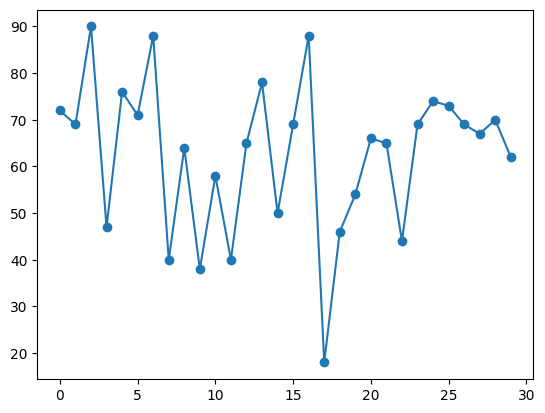

In [ ]:
plt.plot(df["Math"][:30], marker='o')
plt.show()


Bar chart (individual colors + labels)

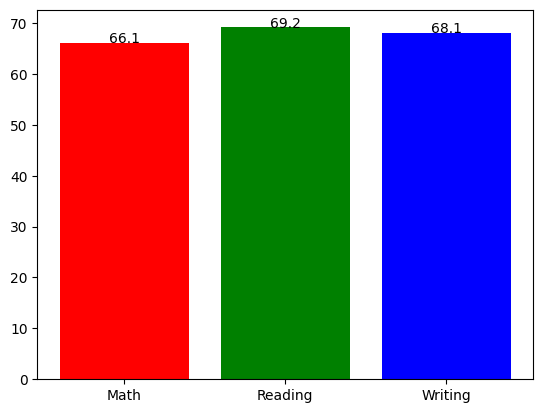

In [ ]:
means = df[["Math","Reading","Writing"]].mean()
plt.bar(means.index, means.values, color=['r','g','b'])
for i,v in enumerate(means):
    plt.text(i, v, f"{v:.1f}", ha='center')
plt.show()


Stacked Bar Chart

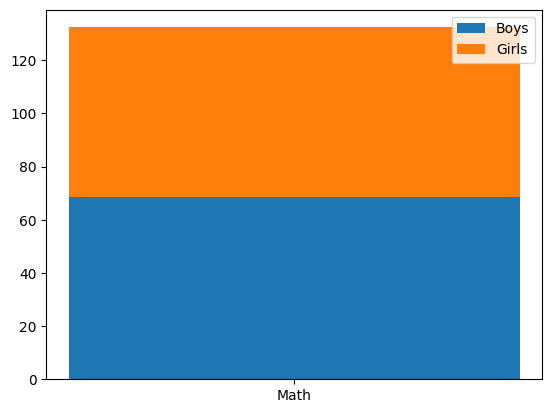

In [ ]:
boys = df[df.Gender=="male"]["Math"].mean()
girls = df[df.Gender=="female"]["Math"].mean()

plt.bar("Math", boys, label="Boys")
plt.bar("Math", girls, bottom=boys, label="Girls")
plt.legend()
plt.show()


Grouped Bar Chart with Labels

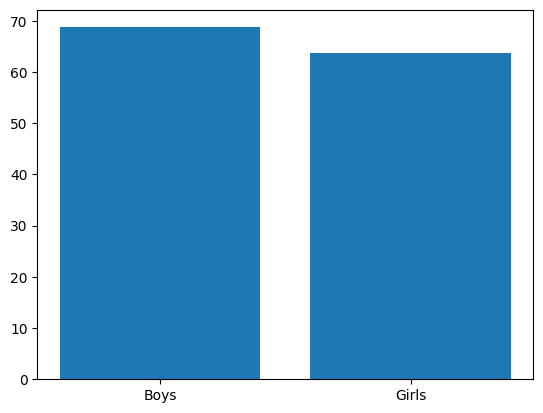

In [ ]:
plt.bar(["Boys","Girls"], [boys, girls])
plt.show()


Horizontal & Broken Bars

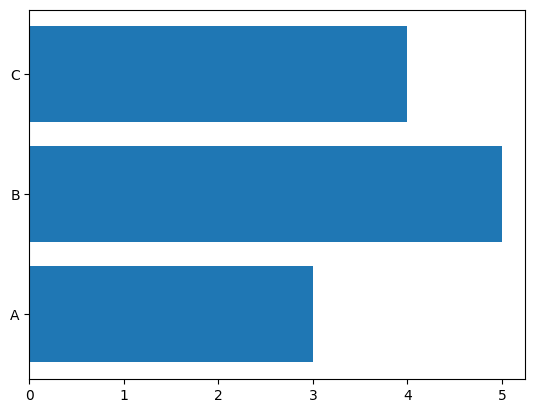

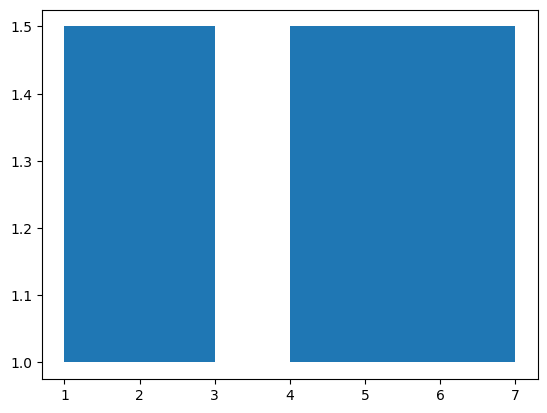

In [ ]:
plt.barh(["A","B","C"], [3,5,4])
plt.show()

plt.broken_barh([(1,2),(4,3)], (1,0.5))
plt.show()


Plotting Categorical Variables

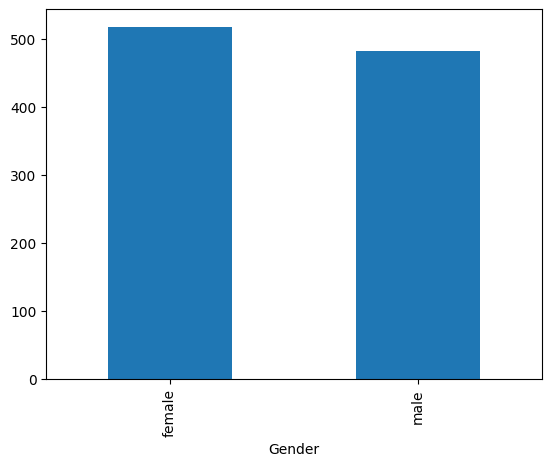

In [ ]:
df["Gender"].value_counts().plot(kind="bar")
plt.show()


Scatter Plots (all variants)Scatter Demo2
Scatter with legend
Scatter with histograms
Scatter with masked values

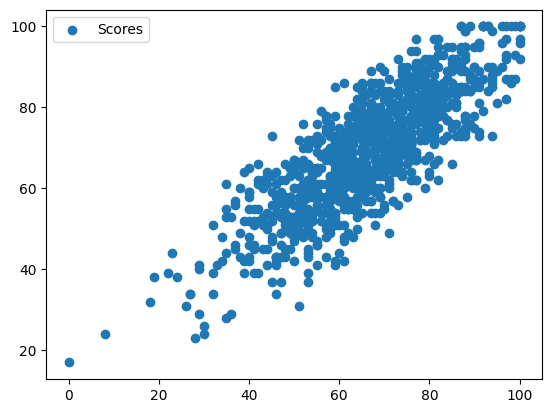

In [ ]:
plt.scatter(df["Math"], df["Reading"], label="Scores")
plt.legend()
plt.show()


Marker examples, Marker reference, Markevery

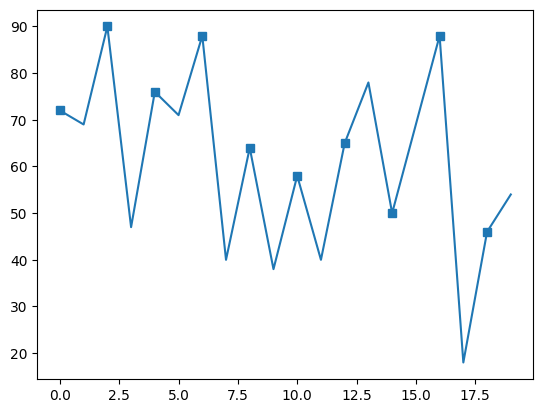

In [ ]:
plt.plot(df["Math"][:20], marker='s', markevery=2)
plt.show()


Multicolored lines

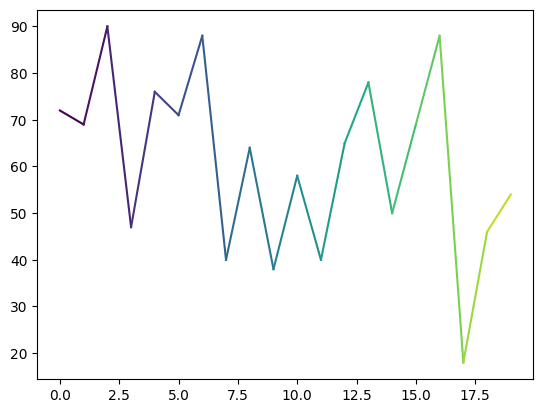

In [ ]:
y = df["Math"][:20].values
for i in range(len(y)-1):
    plt.plot([i,i+1], [y[i],y[i+1]], color=plt.cm.viridis(i/20))
plt.show()


Mapping marker properties to multivariate data

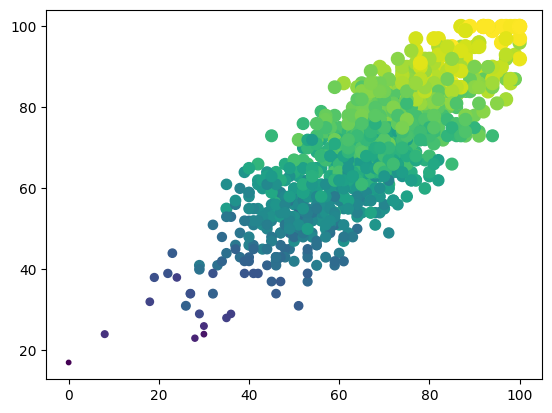

In [ ]:
plt.scatter(df["Math"], df["Reading"],
            s=df["Writing"], c=df["Writing"])
plt.show()


Plotting masked & NaN values

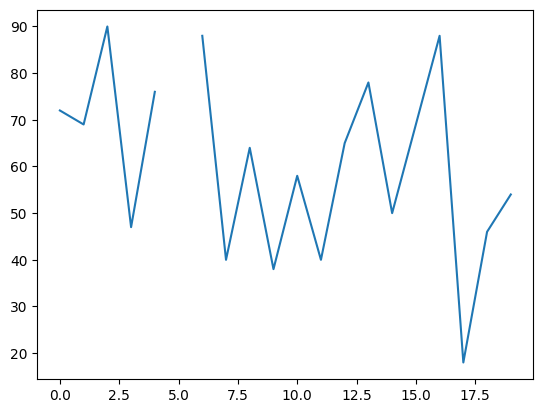

In [ ]:
y = df["Math"][:20].astype(float)
y[5] = np.nan
plt.plot(y)
plt.show()


Discrete distribution (horizontal)

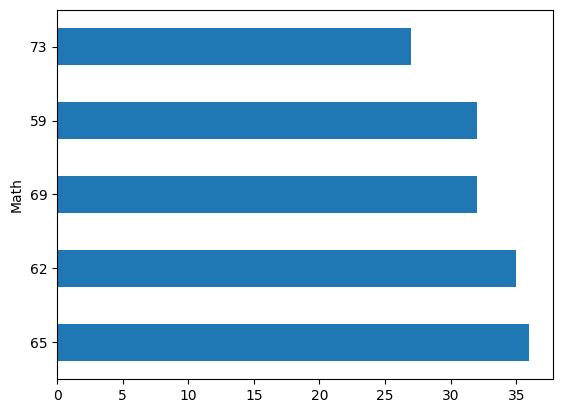

In [ ]:
df["Math"].value_counts().head(5).plot(kind="barh")
plt.show()


Hat graph

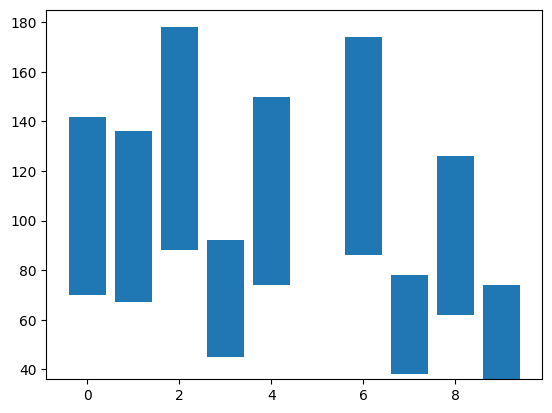

In [ ]:
plt.bar(range(10), y[:10], bottom=y[:10]-2)
plt.show()


Stackplots & Streamgraphs

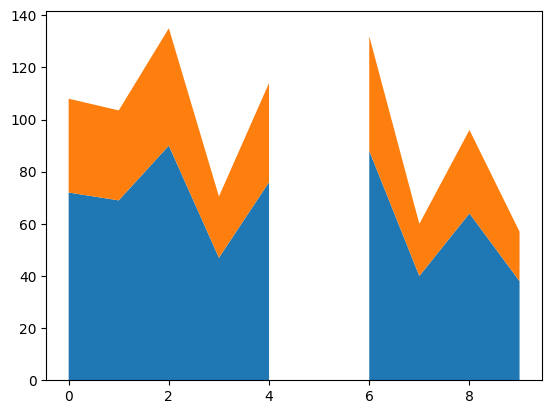

In [ ]:
plt.stackplot(range(10), y[:10], y[:10]/2)
plt.show()


stairs, Stem, Step

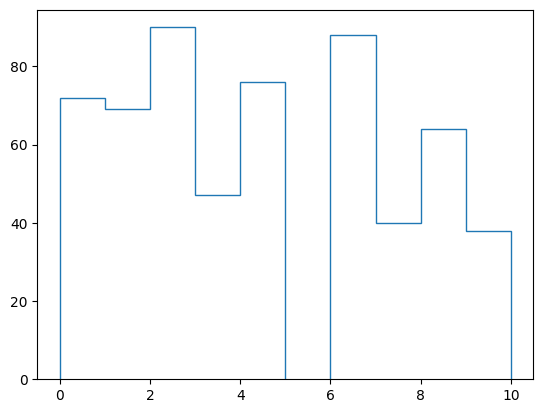

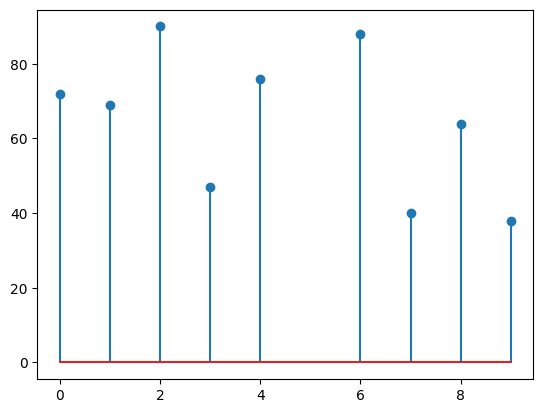

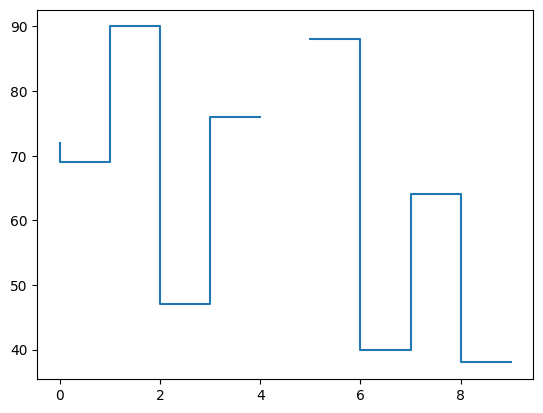

In [ ]:
plt.stairs(y[:10]); plt.show()
plt.stem(y[:10]); plt.show()
plt.step(range(10), y[:10]); plt.show()


Timeline with dates

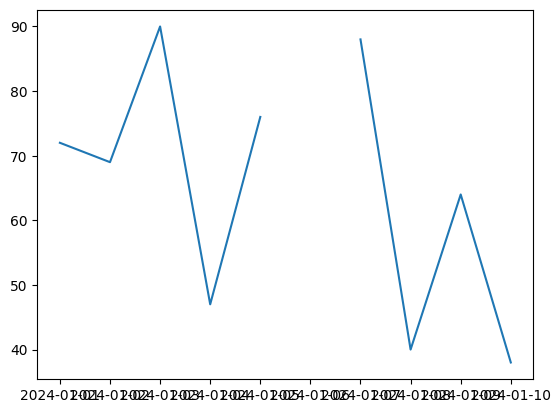

In [ ]:
dates = pd.date_range("2024-01-01", periods=10)
plt.plot(dates, y[:10])
plt.show()


Signal Analysis & Advanced Matplotlib using Noisy Time-Series Data

In [ ]:
from google.colab import files
uploaded = files.upload()


Load & Basic Cleaning

In [ ]:
from scipy import signal

ecg = pd.read_csv("mitbih_train.csv", header=None)
raw = ecg.iloc[0,:-1].values

filtered = signal.savgol_filter(raw, 31, 3)


Infinite lines (hlines & vlines)

In [ ]:
plt.plot(raw[:500])
plt.hlines(0, 0, 500)
plt.vlines(250, -2, 2)
plt.show()


CapStyle & JoinStyle

In [ ]:
plt.plot([0,1,2],[1,3,2], linewidth=8,
         solid_capstyle='round',
         solid_joinstyle='bevel')
plt.show()


Dashed line configuration & Linestyles

In [ ]:
plt.plot(raw[:300], linestyle=(0,(5,2)))
plt.show()


Curve with error band

In [ ]:
plt.plot(filtered[:300])
plt.fill_between(range(300),
                 filtered[:300]-0.2,
                 filtered[:300]+0.2,
                 alpha=0.3)
plt.show()


Errorbar limit selection & subsampling

In [ ]:
x = range(0,300,20)
plt.errorbar(x, filtered[x], yerr=0.3, uplims=True)
plt.show()


EventCollection & Eventplot

In [ ]:
from matplotlib.collections import EventCollection

events = [50,120,200]
fig, ax = plt.subplots()
ax.add_collection(EventCollection(events))
plt.show()

plt.eventplot(events)
plt.show()


Filled polygon

In [ ]:
from matplotlib.patches import Polygon
poly = Polygon([[50,0],[100,1],[150,0]])
plt.gca().add_patch(poly)
plt.show()


Fill between two vertical lines

In [ ]:
plt.plot(filtered[:300])
plt.axvspan(100,150,alpha=0.3)
plt.show()


Power Spectral Density (PSD)

In [ ]:
f, Pxx = signal.welch(raw, fs=360)
plt.semilogy(f, Pxx)
plt.show()


Cross Spectral Density (CSD)

In [ ]:
f, Pxy = signal.csd(raw, filtered, fs=360)
plt.semilogy(f, abs(Pxy))
plt.show()


Coherence

In [ ]:
f, Cxy = signal.coherence(raw, filtered, fs=360)
plt.plot(f, Cxy)
plt.show()


Spectrum representations

In [ ]:
plt.magnitude_spectrum(raw, Fs=360)
plt.show()


Cross- & Auto-correlation

In [ ]:
plt.plot(signal.correlate(raw, raw, mode="full"))
plt.show()

plt.plot(signal.correlate(raw, filtered, mode="full"))
plt.show()
